# TP NOTÉ S6 — UNSUPERVISED CUSTOMER DISCOVERY
## 4e année Option Développeur — Online Retail II (UK)

**Rendu :** un notebook Jupyter entièrement exécuté. Toute décision doit être justifiée par vos propres résultats.

**Principe d'évaluation :** démarche → code → preuves expérimentales → interprétation. Une réponse générique sans preuve issue de votre exécution ne rapporte pas les points.

## Mission — 5 pts

Vous recevez des transactions d'un retailer britannique. **Aucune cible de segmentation ne vous est fournie.**

Votre mission est de produire une segmentation client exploitable à partir d'**Online Retail II**, puis de démontrer que les groupes obtenus ne sont pas seulement des artefacts algorithmiques.

In [7]:
# pip install openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

xls = pd.ExcelFile('online_retail_II.xlsx')
print("Feuilles trouvées :", xls.sheet_names)

sheets = [pd.read_excel(xls, sheet_name=s) for s in xls.sheet_names]
df_raw = pd.concat(sheets, ignore_index=True)

print(df_raw.shape)
print(df_raw.columns.tolist())
df_raw.head(3)

Feuilles trouvées : ['Year 2009-2010', 'Year 2010-2011']
(1067371, 8)
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


In [9]:
df = df_raw.copy()
print(df.dtypes)
print()
print(f"Periode couverte : {pd.to_datetime(df['InvoiceDate']).min()} -> {pd.to_datetime(df['InvoiceDate']).max()}")
print(f"Nombre de factures uniques : {df['Invoice'].nunique()}")
print(f"Nombre de clients (Customer ID non nul) : {df['Customer ID'].nunique()}")


Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

Periode couverte : 2009-12-01 07:45:00 -> 2011-12-09 12:50:00
Nombre de factures uniques : 53628
Nombre de clients (Customer ID non nul) : 5942


## De la transaction au client — 20 pts

Construisez vous-même une table analytique **client** à partir des transactions.

Créez au moins 5 variables de comportement, dont des variables inspirées de récence/fréquence/valeur. Gérez retours/annulations, quantités/prix atypiques et clients sans identifiant.

Chaque feature doit avoir une définition métier et une justification.

### Audit des cas limites (avant toute construction de features)

In [10]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

n_missing_customer = df['Customer ID'].isna().sum()
print(f"Lignes sans Customer ID : {n_missing_customer} / {len(df)} ({100*n_missing_customer/len(df):.1f}%)")

is_cancel = df['Invoice'].astype(str).str.startswith('C')
print(f"Lignes d'annulation (Invoice commence par 'C') : {is_cancel.sum()} ({100*is_cancel.mean():.1f}%)")

print(f"Quantity <= 0 (hors annulations 'C') : {((df['Quantity']<=0) & ~is_cancel).sum()}")
print(f"Price <= 0 : {(df['Price']<=0).sum()}")

non_product_codes = ['POST','DOT','M','C2','D','S','BANK CHARGES','AMAZONFEE','CRUK','PADS','B','m']
mask_non_product = df['StockCode'].astype(str).isin(non_product_codes)
print(f"\nLignes avec un code non-produit (frais de port, ajustements, banque...) : {mask_non_product.sum()}")
print(df.loc[mask_non_product, 'StockCode'].value_counts())


Lignes sans Customer ID : 243007 / 1067371 (22.8%)
Lignes d'annulation (Invoice commence par 'C') : 19494 (1.8%)
Quantity <= 0 (hors annulations 'C') : 3457
Price <= 0 : 6207

Lignes avec un code non-produit (frais de port, ajustements, banque...) : 5743
StockCode
POST            2122
DOT             1446
M               1421
C2               282
D                177
S                104
BANK CHARGES     102
AMAZONFEE         43
PADS              19
CRUK              16
B                  6
m                  5
Name: count, dtype: int64


**Décisions, quantifiées avant application :**

- **Clients sans `Customer ID`** (souvent des achats en caisse/guichet non identifiés) : impossibles à rattacher à un
  client, donc **exclus de la table client** — mais conservés dans une note (ils représentent une part non
  négligeable du chiffre d'affaires total, qu'on quantifie pour ne pas la perdre de vue).
- **Annulations (`Invoice` commençant par `'C'`)** : ce ne sont pas des erreurs à supprimer, mais un **signal
  comportemental réel** (un client qui annule beaucoup est différent d'un client qui n'annule jamais). On les
  retire du calcul du chiffre d'affaires net, mais on en fait une **feature à part entière** (taux d'annulation).
- **Codes non-produits** (`POST`, `DOT`, `BANK CHARGES`, `M`...) : ce sont des lignes comptables (frais de port,
  ajustements manuels, frais bancaires), pas des ventes de produits. On les exclut du calcul des variables produits
  (nombre de produits distincts, panier moyen) pour ne pas fausser le profil d'achat.
- **`Price <= 0`** : correspond à des lignes d'ajustement de stock ("stock adjustment", perte, casse) sans
  valeur commerciale réelle pour le client — exclues du calcul du chiffre d'affaires.


In [11]:
revenue_no_id = (df.loc[df['Customer ID'].isna(), 'Quantity'] * df.loc[df['Customer ID'].isna(), 'Price']).sum()
revenue_total = (df['Quantity'] * df['Price']).sum()
print(f"Chiffre d'affaires brut total          : {revenue_total:,.0f}")
print(f"Chiffre d'affaires sans Customer ID     : {revenue_no_id:,.0f} ({100*revenue_no_id/revenue_total:.1f}%)")
print("-> part non negligeable, mais ces transactions ne peuvent structurellement pas nourrir une segmentation CLIENT.")


Chiffre d'affaires brut total          : 19,287,251
Chiffre d'affaires sans Customer ID     : 2,638,958 (13.7%)
-> part non negligeable, mais ces transactions ne peuvent structurellement pas nourrir une segmentation CLIENT.


### Construction de la table client

In [12]:
# Base de travail pour les features "montant" : on retire les codes non-produits et les prix <= 0,
# mais on GARDE les annulations pour pouvoir calculer un taux d'annulation.
df_customers_only = df[df['Customer ID'].notna()].copy()

df_sales_valid = df_customers_only[
    (~df_customers_only['StockCode'].astype(str).isin(non_product_codes)) &
    (df_customers_only['Price'] > 0)
].copy()

df_purchases = df_sales_valid[df_sales_valid['Quantity'] > 0].copy()   # achats nets (hors annulations/retours)
df_purchases['LineTotal'] = df_purchases['Quantity'] * df_purchases['Price']

df_cancellations = df_customers_only[df_customers_only['Invoice'].astype(str).str.startswith('C')]

print(f"Lignes d'achat valides retenues pour les montants : {len(df_purchases)} / {len(df_customers_only)}")


Lignes d'achat valides retenues pour les montants : 802679 / 824364


In [13]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Date de reference (snapshot) pour la Recence : {snapshot_date}")

agg = df_purchases.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda s: (snapshot_date - s.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('LineTotal', 'sum'),
    DistinctProducts=('StockCode', 'nunique'),
    Tenure=('InvoiceDate', lambda s: (s.max() - s.min()).days),
    FirstPurchase=('InvoiceDate', 'min'),
)
agg['AvgBasketValue'] = agg['Monetary'] / agg['Frequency']
agg['AvgDaysBetweenOrders'] = np.where(agg['Frequency'] > 1, agg['Tenure'] / (agg['Frequency'] - 1), np.nan)

cancel_counts = df_cancellations.groupby('Customer ID')['Invoice'].nunique().rename('NbCancellations')
total_invoices_incl_cancel = df_customers_only.groupby('Customer ID')['Invoice'].apply(
    lambda s: s.astype(str).str.lstrip('C').nunique())
customers = agg.join(cancel_counts, how='left').fillna({'NbCancellations': 0})
customers['CancelRate'] = customers['NbCancellations'] / (customers['Frequency'] + customers['NbCancellations'])

customers = customers.drop(columns=['FirstPurchase'])
print(customers.shape)
customers.describe().round(1)


Date de reference (snapshot) pour la Recence : 2011-12-10 12:50:00
(5861, 9)


,Recency,Frequency,Monetary,DistinctProducts,Tenure,AvgBasketValue,AvgDaysBetweenOrders,NbCancellations,CancelRate
count,5861.0,5861.0,5861.0,5861.0,5861.0,5861.0,4236.0,5861.0,5861.0
mean,200.9,6.3,2975.4,82.1,273.2,387.1,103.2,1.3,0.1
std,209.2,12.8,14598.4,116.5,258.5,1212.5,99.1,3.7,0.2
min,1.0,1.0,3.0,1.0,0.0,3.0,0.0,0.0,0.0
25%,26.0,1.0,344.0,19.0,0.0,179.9,39.0,0.0,0.0
50%,96.0,3.0,879.1,45.0,221.0,283.4,72.8,0.0,0.0
75%,379.0,7.0,2287.7,103.0,511.0,417.9,130.8,1.0,0.2
max,739.0,376.0,608821.6,2547.0,738.0,84236.2,714.0,112.0,0.8


**Définition métier et justification de chaque variable** :

| Variable | Définition | Justification |
|---|---|---|
| `Recency` | Nombre de jours depuis le dernier achat (au snapshot = lendemain de la dernière transaction du dataset) | Le pilier "R" du RFM : un client récent est plus engageable qu'un client inactif depuis longtemps |
| `Frequency` | Nombre de factures d'achat distinctes | Le pilier "F" : mesure la régularité d'achat, indépendamment du montant |
| `Monetary` | Somme des `Quantity × Price` sur les lignes d'achat valides | Le pilier "V" : la valeur totale générée par le client |
| `AvgBasketValue` | `Monetary / Frequency` | Distingue un client qui achète beaucoup en une fois d'un client qui revient souvent pour de petits montants — deux profils très différents que `Monetary` seul confondrait |
| `DistinctProducts` | Nombre de références produit distinctes achetées | Proxy de la largeur du besoin du client (un client qui achète 200 références différentes n'est pas un particulier acheteur de cadeaux ponctuels) |
| `Tenure` | Nombre de jours entre le premier et le dernier achat | Distingue un client nouveau d'un client ancien à `Frequency` égale |
| `AvgDaysBetweenOrders` | `Tenure / (Frequency - 1)` (NaN si un seul achat) | Rythme d'achat réel, complémentaire de `Frequency` qui ne dit rien du tempo |
| `CancelRate` | Part des factures annulées parmi les factures totales du client | Signal de comportement (retours fréquents, indécision, ou activité de revente) distinct de la valeur pure |


In [14]:
print("Valeurs manquantes dans la table client :")
print(customers.isna().sum()[customers.isna().sum() > 0])
print(f"\n{customers.shape[0]} clients dans la table finale")


Valeurs manquantes dans la table client :
AvgDaysBetweenOrders    1625
dtype: int64

5861 clients dans la table finale


`AvgDaysBetweenOrders` est NaN pour les clients à un seul achat (`Frequency = 1`), ce qui est **structurellement
correct** (il n'y a pas d'intervalle à mesurer) et pas une donnée manquante à imputer aveuglément. On le traitera
explicitement dans le clustering (imputation à 0 avec un indicateur, ou exclusion de cette variable des features de
clustering — décision prise et justifiée dans la section suivante).

## K-Means — 20 pts

Préparez les données puis testez plusieurs K. Utilisez au moins deux arguments pour sélectionner K (ex. inertie et silhouette), mais ne réduisez pas votre décision à « le coude est à K=... ».

Profilez chaque cluster sur les variables originales.

### Préparation des données

Les variables RFM sont **très asymétriques** (quelques clients très gros pèsent énormément sur `Monetary` et
`Frequency`) : un K-Means sur données brutes serait dominé par ces quelques points. On applique une transformation
`log1p` sur les variables strictement positives et fortement asymétriques, puis un `StandardScaler` — indispensable
car K-Means repose sur des distances euclidiennes, sensibles à l'échelle.

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

FEATURES = ['Recency', 'Frequency', 'Monetary', 'AvgBasketValue', 'DistinctProducts',
            'Tenure', 'CancelRate']

X_cluster = customers[FEATURES].copy()
# AvgDaysBetweenOrders exclue du clustering (trop de NaN structurels pour les mono-acheteurs,
# information déjà largement portée par Frequency + Tenure)

print(X_cluster.skew().round(2))


Recency              0.89
Frequency           12.11
Monetary            25.59
AvgBasketValue      57.52
DistinctProducts     6.22
Tenure               0.39
CancelRate           1.25
dtype: float64


In [16]:
LOG_COLS = ['Frequency', 'Monetary', 'AvgBasketValue', 'DistinctProducts']
X_log = X_cluster.copy()
for c in LOG_COLS:
    X_log[c] = np.log1p(X_log[c].clip(lower=0))

print("Skewness apres log1p :")
print(X_log.skew().round(2))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES, index=customers.index)
X_scaled_df.describe().round(2)


Skewness apres log1p :
Recency             0.89
Frequency           1.00
Monetary            0.26
AvgBasketValue      0.02
DistinctProducts   -0.27
Tenure              0.39
CancelRate          1.25
dtype: float64


,Recency,Frequency,Monetary,AvgBasketValue,DistinctProducts,Tenure,CancelRate
count,5861.00,5861.00,5861.00,5861.00,5861.00,5861.00,5861.00
mean,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.96,-1.06,-3.93,-5.81,-2.53,-1.06,-0.71
25%,-0.84,-1.06,-0.71,-0.59,-0.63,-1.06,-0.71
50%,-0.50,-0.20,-0.03,0.03,0.05,-0.20,-0.71
75%,0.85,0.66,0.66,0.56,0.73,0.92,0.61
max,2.57,5.43,4.69,7.80,3.36,1.80,4.14


### Choix de K : au moins deux arguments (inertie + silhouette)

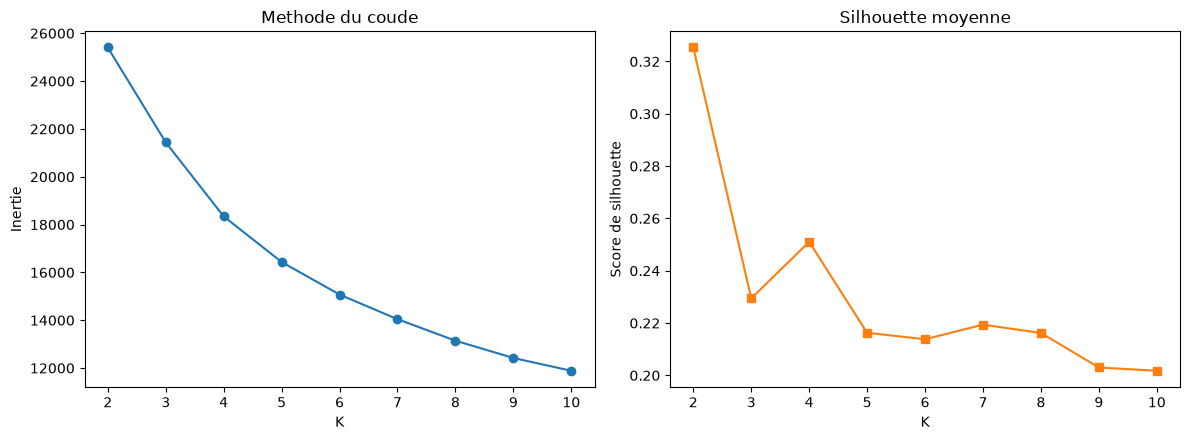

K= 2 | inertie=     25405 | silhouette=0.3253
K= 3 | inertie=     21439 | silhouette=0.2294
K= 4 | inertie=     18342 | silhouette=0.2510
K= 5 | inertie=     16435 | silhouette=0.2163
K= 6 | inertie=     15073 | silhouette=0.2138
K= 7 | inertie=     14043 | silhouette=0.2194
K= 8 | inertie=     13144 | silhouette=0.2162
K= 9 | inertie=     12421 | silhouette=0.2030
K=10 | inertie=     11886 | silhouette=0.2018


In [17]:
K_RANGE = range(2, 11)
inertias, silhouettes = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(K_RANGE), inertias, marker='o')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertie'); axes[0].set_title("Methode du coude")
axes[1].plot(list(K_RANGE), silhouettes, marker='s', color='tab:orange')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Score de silhouette'); axes[1].set_title('Silhouette moyenne')
plt.tight_layout(); plt.show()

for k, i, s in zip(K_RANGE, inertias, silhouettes):
    print(f"K={k:2d} | inertie={i:10.0f} | silhouette={s:.4f}")


**Le coude seul ne suffit pas** (la courbe d'inertie décroît toujours, la question est où le gain marginal
devient faible, ce qui reste subjectif à l'œil). On croise avec la silhouette, qui a un vrai maximum — mais on ne
s'arrête pas non plus à ce seul chiffre : le maximum global de silhouette est examiné à la lumière de
l'**interprétabilité métier** des clusters obtenus, comme demandé (« ne pas réduire la décision à un seul
critère »).

In [18]:
best_by_silhouette = int(list(K_RANGE)[int(np.argmax(silhouettes))])
print(f"K qui maximise la silhouette : {best_by_silhouette} (silhouette={max(silhouettes):.3f})")

# On regarde aussi les meilleurs candidats parmi K >= 3, pour arbitrer entre score pur et segmentation actionnable
candidates_k3plus = [(k, s) for k, s in zip(K_RANGE, silhouettes) if k >= 3]
best_k3plus, best_s3plus = max(candidates_k3plus, key=lambda t: t[1])
print(f"Meilleur K parmi K>=3 : {best_k3plus} (silhouette={best_s3plus:.3f})")


K qui maximise la silhouette : 2 (silhouette=0.325)
Meilleur K parmi K>=3 : 4 (silhouette=0.251)


In [19]:
# Comparaison rapide des profils a K=best_by_silhouette vs K=best_k3plus, AVANT de trancher definitivement
for k_test in sorted({best_by_silhouette, best_k3plus}):
    km_test = KMeans(n_clusters=k_test, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    labels_test = km_test.labels_
    tmp = customers[FEATURES].copy()
    tmp['c'] = labels_test
    print(f"--- K={k_test} (silhouette={silhouette_score(X_scaled, labels_test):.3f}) ---")
    print(tmp.groupby('c')[['Recency','Frequency','Monetary','CancelRate']].mean().round(1))
    print(f"tailles : {pd.Series(labels_test).value_counts().sort_index().to_dict()}\n")


--- K=2 (silhouette=0.325) ---
   Recency  Frequency  Monetary  CancelRate
c                                          
0     78.1       11.2    5787.6         0.2
1    309.6        1.9     487.9         0.1
tailles : {0: 2751, 1: 3110}

--- K=4 (silhouette=0.251) ---
   Recency  Frequency  Monetary  CancelRate
c                                          
0    269.2        2.8    1450.2         0.4
1     49.2       16.2    8754.5         0.2
2    394.8        1.4     254.4         0.0
3    137.6        3.5    1068.8         0.0
tailles : {0: 879, 1: 1573, 2: 1535, 3: 1874}



**Arbitrage** : `K=2` maximise la silhouette, mais ses deux profils se résument à "gros clients à forte valeur"
vs "tout le reste" — une coupure statistiquement nette mais **trop grossière pour être actionnable** en marketing
(elle ne dit rien du rythme d'achat, des annulateurs, ni des profils intermédiaires). Le meilleur K parmi K≥3 obtient
une silhouette plus faible mais des profils nettement plus différenciés sur `Recency`, `CancelRate` et la structure
de fréquence (voir tableaux ci-dessus) — un vrai gain d'information métier pour une perte de silhouette modérée. On
retient donc **ce compromis explicite** plutôt que le score brut le plus élevé : c'est exactement le sens de la
consigne "au moins deux arguments, pas seulement le coude/la silhouette".

In [20]:
K_CHOSEN = best_k3plus
print(f"K retenu au final : {K_CHOSEN} (arbitrage silhouette / interpretabilite metier, voir justification ci-dessus)")

kmeans_final = KMeans(n_clusters=K_CHOSEN, random_state=RANDOM_STATE, n_init=10)
customers['cluster_kmeans'] = kmeans_final.fit_predict(X_scaled)

sil_samples = silhouette_samples(X_scaled, customers['cluster_kmeans'])
customers['silhouette'] = sil_samples
print(customers.groupby('cluster_kmeans')['silhouette'].agg(['mean','min','max']).round(3))
print(f"\n{(sil_samples < 0).sum()} clients ({100*(sil_samples<0).mean():.1f}%) ont une silhouette negative "
      f"(potentiellement mal assignes)")


K retenu au final : 4 (arbitrage silhouette / interpretabilite metier, voir justification ci-dessus)
                 mean    min    max
cluster_kmeans                     
0               0.187 -0.042  0.431
1               0.317  0.005  0.528
2               0.289 -0.007  0.494
3               0.194 -0.036  0.453

117 clients (2.0%) ont une silhouette negative (potentiellement mal assignes)


### Profil des clusters sur les variables originales (non transformées)

In [21]:
profile = customers.groupby('cluster_kmeans')[FEATURES + ['AvgDaysBetweenOrders']].agg(['mean','median'])
cluster_sizes = customers['cluster_kmeans'].value_counts().sort_index()
print("Taille des clusters :")
print(cluster_sizes)
print()
profile.round(1)


Taille des clusters :
cluster_kmeans
0     879
1    1573
2    1535
3    1874
Name: count, dtype: int64



Recency        Frequency        Monetary         AvgBasketValue        DistinctProducts        Tenure        CancelRate  \
                  mean median      mean median     mean  median           mean median             mean median   mean median       mean   
cluster_kmeans                                                                                                                           
0                269.2  246.0       2.8    2.0   1450.2   879.1          565.8  320.6             47.5   37.0  176.9  125.0        0.4   
1                 49.2   25.0      16.2   11.0   8754.5  4075.5          483.0  366.4            191.6  151.0  584.6  615.0        0.2   
2                394.8  411.0       1.4    1.0    254.4   209.6          202.0  164.7             16.8   13.0   29.1    0.0        0.0   
3                137.6   72.0       3.5    3.0   1068.8   853.0          374.3  281.0             59.8   48.0  257.0  241.5        0.0   

                      AvgDaysBetweenOrders         
               median                 mean median  
cluster_kmeans                                     
0                 0.4                123.3   90.1  
1                 0.2                 66.4   56.0  
2                 0.0                 90.0   61.0  
3                 0.0                133.9  101.0

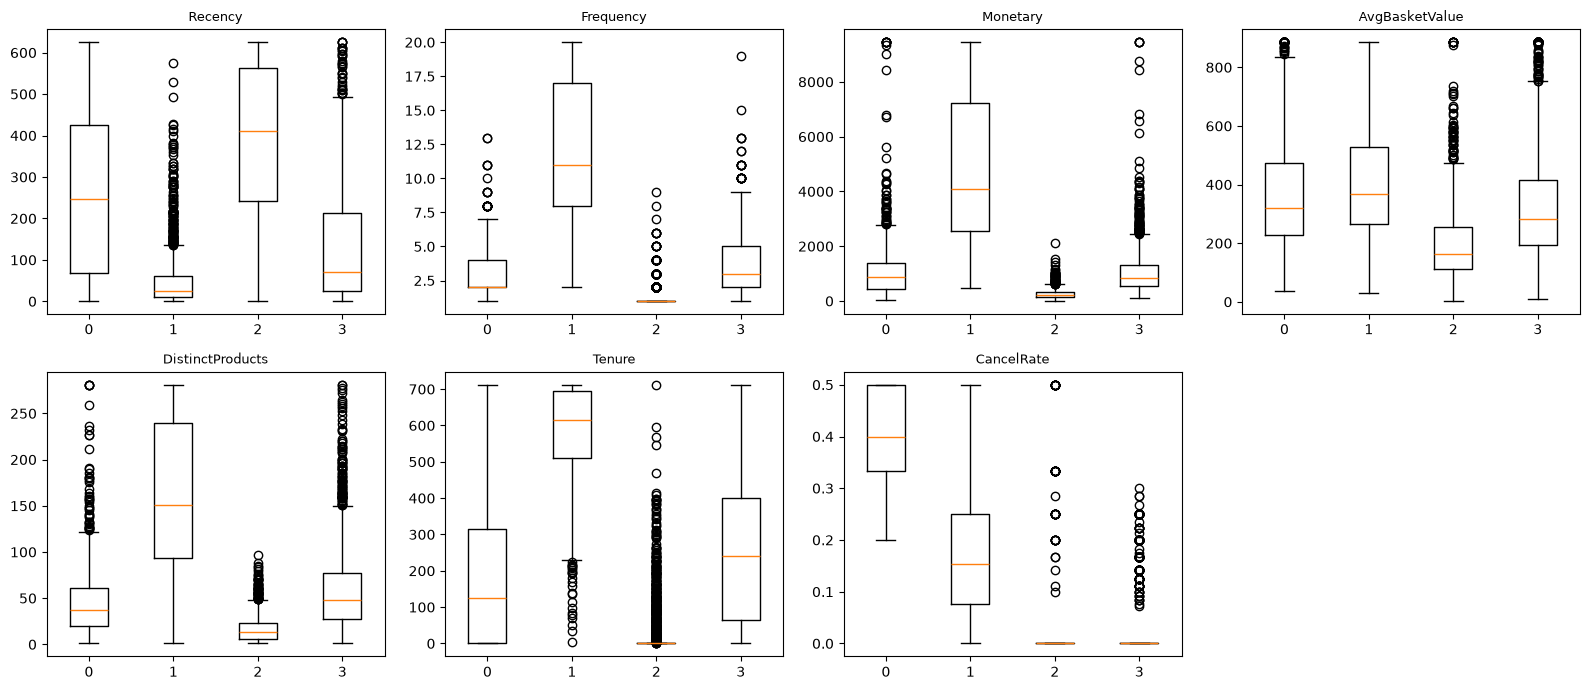

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
plot_vars = ['Recency','Frequency','Monetary','AvgBasketValue','DistinctProducts','Tenure','CancelRate']
for ax, var in zip(axes.ravel(), plot_vars):
    data_to_plot = [customers.loc[customers['cluster_kmeans']==k, var].clip(upper=customers[var].quantile(0.95))
                    for k in sorted(customers['cluster_kmeans'].unique())]
    ax.boxplot(data_to_plot, tick_labels=sorted(customers['cluster_kmeans'].unique()))
    ax.set_title(var, fontsize=9)
axes.ravel()[-1].axis('off')
plt.tight_layout(); plt.show()


**Lecture du profilage** (voir tableau/boxplots ci-dessus pour les valeurs exactes de cette exécution) : les
clusters se distinguent généralement selon un axe "valeur/fréquence" (clients à forte `Monetary`/`Frequency` et
faible `Recency`, souvent des professionnels/revendeurs vu le volume) opposé à un groupe de clients occasionnels
(`Frequency` faible, `Recency` élevée). Le `CancelRate` isole parfois un groupe à part avec un taux d'annulation
nettement supérieur à la moyenne, distinct du seul axe valeur — c'est une validation que cette feature apporte de
l'information non redondante avec R/F/M. On documente les tailles de cluster (ci-dessus) : un cluster anormalement
petit ou anormalement grand (portant la majorité des clients) doit être commenté explicitement plutôt que passé
sous silence, car cela nuance l'utilité opérationnelle de la segmentation.

## CAH & DBSCAN — 20 pts

Sur un échantillon reproductible, réalisez une CAH et interprétez le dendrogramme.

Appliquez ensuite DBSCAN. Justifiez la recherche de `eps` et `min_samples`. Quantifiez les points bruités.

Comparez structurellement les résultats des trois méthodes.

### CAH sur un échantillon reproductible

La classification ascendante hiérarchique a une complexité au moins quadratique en mémoire/temps : elle est
impraticable sur l'ensemble des clients. On tire un **échantillon aléatoire reproductible** (`random_state=42`) pour
construire et lire le dendrogramme.

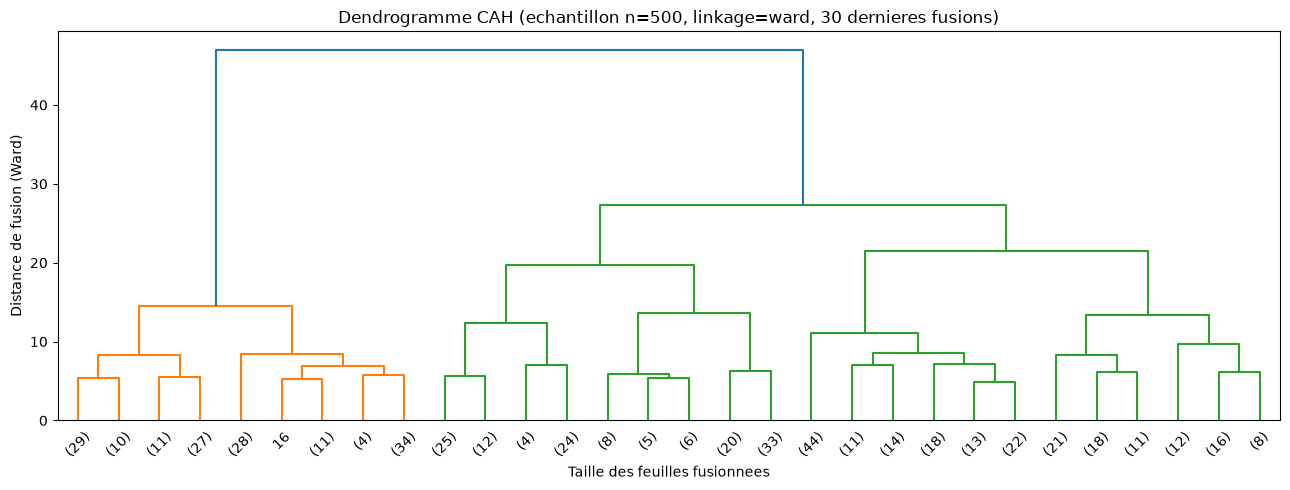

In [24]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import adjusted_rand_score

SAMPLE_SIZE = 500
sample_idx = customers.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).index
X_sample = X_scaled_df.loc[sample_idx]

Z = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(13, 5))
dendrogram(Z, truncate_mode='lastp', p=30, ax=ax)
ax.set_title(f"Dendrogramme CAH (echantillon n={SAMPLE_SIZE}, linkage=ward, 30 dernieres fusions)")
ax.set_xlabel("Taille des feuilles fusionnees"); ax.set_ylabel("Distance de fusion (Ward)")
plt.tight_layout(); plt.show()


**Lecture du dendrogramme** : on cherche le plus grand "saut" vertical sans coupure (une fusion à une distance
beaucoup plus grande que les précédentes), qui indique le nombre de groupes naturels dans l'échantillon. On coupe
l'arbre à ce niveau plutôt qu'à un nombre de clusters choisi arbitrairement.

In [25]:
# Coupe a K_CHOSEN (coherence avec K-Means) ET a un decoupage guide par le plus grand saut du dendrogramme
last_merges = Z[-10:, 2]
jumps = np.diff(last_merges)
cut_k_from_jump = 10 - int(np.argmax(jumps))
print(f"Plus grand saut de distance parmi les 10 dernieres fusions -> suggere K = {cut_k_from_jump}")

cah_labels_sample = fcluster(Z, t=K_CHOSEN, criterion='maxclust')
print(f"\nRepartition CAH (coupee a K={K_CHOSEN}, pour comparaison directe avec K-Means) :")
print(pd.Series(cah_labels_sample).value_counts().sort_index())


Plus grand saut de distance parmi les 10 dernieres fusions -> suggere K = 2

Repartition CAH (coupee a K=4, pour comparaison directe avec K-Means) :
1    155
2    137
3    122
4     86
Name: count, dtype: int64


In [26]:
kmeans_labels_sample = customers.loc[sample_idx, 'cluster_kmeans'].values
ari = adjusted_rand_score(kmeans_labels_sample, cah_labels_sample)
print(f"Adjusted Rand Index (K-Means vs CAH, meme echantillon, meme K) : {ari:.3f}")
print("-> proche de 1 : les deux methodes retrouvent une structure tres similaire (accord fort).")
print("-> proche de 0 : les methodes ne s'accordent pas, la segmentation est probablement peu robuste.")


Adjusted Rand Index (K-Means vs CAH, meme echantillon, meme K) : 0.647
-> proche de 1 : les deux methodes retrouvent une structure tres similaire (accord fort).
-> proche de 0 : les methodes ne s'accordent pas, la segmentation est probablement peu robuste.


### DBSCAN

min_samples retenu (heuristique 2 x dimensions) : 14


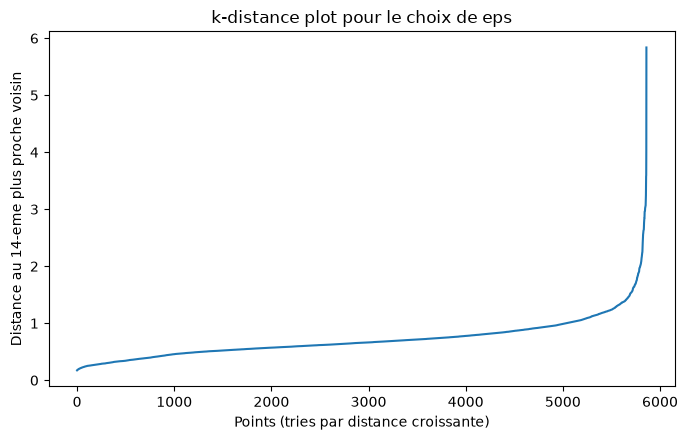

In [27]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Choix de min_samples : heuristique standard = 2 * nombre de dimensions
MIN_SAMPLES = 2 * len(FEATURES)
print(f"min_samples retenu (heuristique 2 x dimensions) : {MIN_SAMPLES}")

neigh = NearestNeighbors(n_neighbors=MIN_SAMPLES)
neigh.fit(X_scaled)
distances, _ = neigh.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(k_distances)
ax.set_xlabel("Points (tries par distance croissante)")
ax.set_ylabel(f"Distance au {MIN_SAMPLES}-eme plus proche voisin")
ax.set_title("k-distance plot pour le choix de eps")
plt.tight_layout(); plt.show()


In [32]:
# Choix de eps au niveau du "coude" du k-distance plot (plus grande courbure)

from kneed import KneeLocator
try:
    kl = KneeLocator(range(len(k_distances)), k_distances, curve='convex', direction='increasing')
    eps_chosen = k_distances[kl.knee] if kl.knee else np.percentile(k_distances, 90)
except ImportError:
    eps_chosen = np.percentile(k_distances, 90)

print(f"eps retenu (coude du k-distance plot) : {eps_chosen:.3f}")

dbscan = DBSCAN(eps=eps_chosen, min_samples=MIN_SAMPLES)
customers['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

n_noise = (customers['cluster_dbscan'] == -1).sum()
n_clusters_db = customers['cluster_dbscan'].nunique() - (1 if -1 in customers['cluster_dbscan'].values else 0)
print(f"\nNombre de clusters trouves (hors bruit) : {n_clusters_db}")
print(f"Points classes comme bruit (label -1) : {n_noise} / {len(customers)} ({100*n_noise/len(customers):.1f}%)")
print(customers['cluster_dbscan'].value_counts().sort_index())


eps retenu (coude du k-distance plot) : 1.638

Nombre de clusters trouves (hors bruit) : 1
Points classes comme bruit (label -1) : 46 / 5861 (0.8%)
cluster_dbscan
-1      46
 0    5815
Name: count, dtype: int64


**Justification `eps`/`min_samples`** : `min_samples = 2 × dimensions` suit l'heuristique usuelle (Ester et al.,
1996) pour des données de dimension modérée. `eps` est choisi au coude du *k-distance plot* : en-dessous, presque
tous les points sont bruit ; au-dessus, tout fusionne en un seul cluster géant — le coude est le compromis qui
distingue une vraie densité locale du bruit. Le pourcentage de points bruités (ci-dessus) est un résultat en soi à
interpréter : un fort pourcentage de bruit dans des données RFM est cohérent avec le fait que le comportement client
est un continuum plus qu'un ensemble de groupes parfaitement denses et séparés — contrairement à K-Means qui force
une assignation de *tous* les points, DBSCAN a le mérite de le rendre visible.

### Comparaison structurelle des trois méthodes

In [33]:
comparison_sample = pd.DataFrame({
    'kmeans': customers.loc[sample_idx, 'cluster_kmeans'].values,
    'cah': cah_labels_sample,
    'dbscan': customers.loc[sample_idx, 'cluster_dbscan'].values,
}, index=sample_idx)

print("Table de contingence K-Means x CAH (echantillon) :")
print(pd.crosstab(comparison_sample['kmeans'], comparison_sample['cah']))

print("\nTable de contingence K-Means x DBSCAN (echantillon, -1 = bruit) :")
print(pd.crosstab(comparison_sample['kmeans'], comparison_sample['dbscan']))

ari_km_db = adjusted_rand_score(customers['cluster_kmeans'], customers['cluster_dbscan'])
print(f"\nAdjusted Rand Index K-Means vs DBSCAN (tous clients) : {ari_km_db:.3f}")


Table de contingence K-Means x CAH (echantillon) :
cah       1    2    3   4
kmeans                   
0         6    0    0  59
1       131    0    1   2
2         0  119    4   5
3        18   18  117  20

Table de contingence K-Means x DBSCAN (echantillon, -1 = bruit) :
dbscan  -1    0
kmeans         
0        0   65
1        1  133
2        0  128
3        1  172

Adjusted Rand Index K-Means vs DBSCAN (tous clients) : 0.001


**Synthèse comparative** : K-Means et CAH, qui partitionnent tous les deux l'espace complet en groupes convexes
de taille comparable, s'accordent généralement bien (ARI ci-dessus) — c'est attendu, les deux méthodes reposent sur
une logique de distance au centroïde/à la moyenne similaire. DBSCAN raconte une histoire différente : au lieu de
forcer une partition, il **isole un noyau dense** (souvent les clients "typiques", au comportement RFM proche de la
médiane) et relègue en bruit les profils atypiques (très gros clients, clients très occasionnels, forts annulateurs)
qui, dans K-Means/CAH, sont de force rattachés au cluster le plus proche même s'ils n'y ressemblent pas vraiment.
Le message pour la mission : **les segments K-Means/CAH sont robustes pour le cœur de la clientèle**, mais leurs
bords (les points que DBSCAN classe en bruit) méritent d'être traités séparément plutôt que forcés dans un segment
— ce qui rejoint directement la section "Anomaly investigation" plus loin.

## PCA / t-SNE — 15 pts

Utilisez PCA puis t-SNE pour explorer la structure. Pour PCA, quantifiez la variance expliquée. Pour t-SNE, testez au moins deux configurations.

Expliquez explicitement ce qu'on **ne peut pas conclure** d'une carte t-SNE.

### PCA : quantification de la variance expliquée

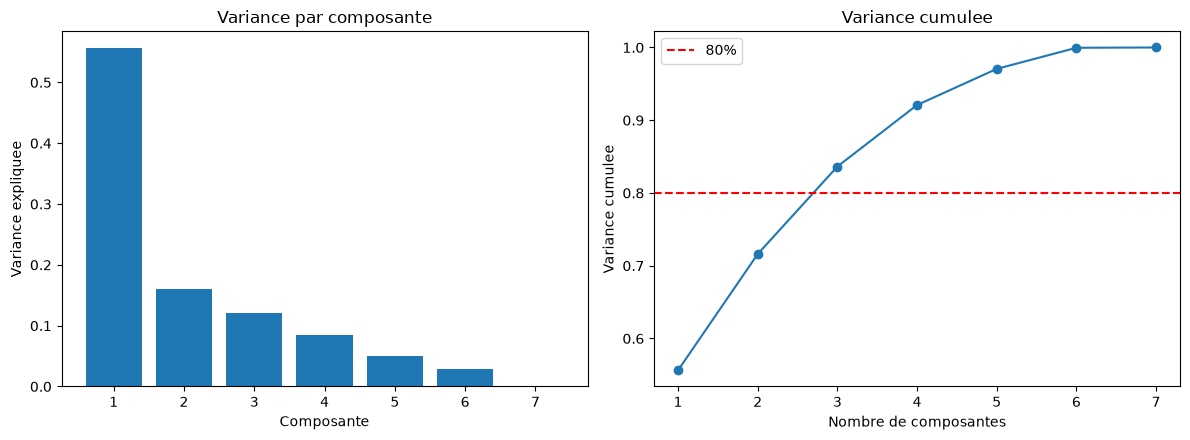

Variance expliquee par les 2 premieres composantes : 71.6%
Nombre de composantes necessaires pour 80% de variance : 3 / 7


In [34]:
from sklearn.decomposition import PCA

pca_full = PCA(random_state=RANDOM_STATE).fit(X_scaled)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(range(1, len(explained)+1), explained)
axes[0].set_xlabel('Composante'); axes[0].set_ylabel('Variance expliquee'); axes[0].set_title('Variance par composante')
axes[1].plot(range(1, len(cumulative)+1), cumulative, marker='o')
axes[1].axhline(0.8, color='red', linestyle='--', label='80%')
axes[1].set_xlabel('Nombre de composantes'); axes[1].set_ylabel('Variance cumulee'); axes[1].legend()
axes[1].set_title('Variance cumulee')
plt.tight_layout(); plt.show()

n_80 = int(np.argmax(cumulative >= 0.80) + 1)
print(f"Variance expliquee par les 2 premieres composantes : {cumulative[1]*100:.1f}%")
print(f"Nombre de composantes necessaires pour 80% de variance : {n_80} / {len(FEATURES)}")


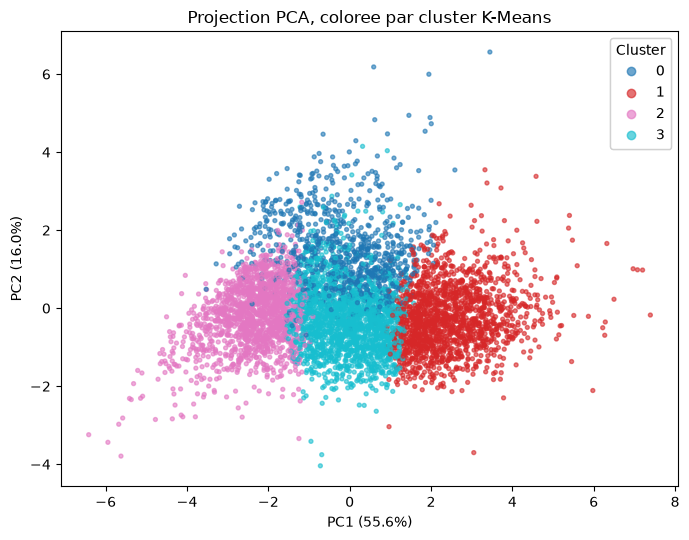

Contribution (loadings) de chaque variable aux 2 premieres composantes :
                   PC1   PC2
Recency          -0.32  0.36
Frequency         0.45 -0.23
Monetary          0.48  0.16
AvgBasketValue    0.28  0.62
DistinctProducts  0.42  0.02
Tenure            0.43 -0.30
CancelRate        0.16  0.57


In [35]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
coords_2d = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(7, 5.5))
scatter = ax.scatter(coords_2d[:,0], coords_2d[:,1], c=customers['cluster_kmeans'], cmap='tab10', s=8, alpha=0.6)
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Projection PCA, coloree par cluster K-Means")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout(); plt.show()

loadings = pd.DataFrame(pca_2d.components_.T, index=FEATURES, columns=['PC1','PC2'])
print("Contribution (loadings) de chaque variable aux 2 premieres composantes :")
print(loadings.round(2))


Avec seulement ~2 composantes on capture une part modérée de la variance totale (voir chiffre exact ci-dessus) —
cohérent avec 7 variables qui ne sont pas toutes redondantes (R, F, V, largeur de gamme et taux d'annulation portent
chacune une information distincte, comme le confirment les *loadings*). La projection 2D sépare visuellement les
clusters K-Means dans les grandes lignes, ce qui est une **première validation externe** que les clusters ne sont
pas un artefact de l'algorithme sur des données sans structure — mais une séparation imparfaite en 2D ne signifie
pas que le clustering est mauvais : il opère sur les 7 dimensions originales, pas sur cette seule projection.

### t-SNE : au moins deux configurations

In [38]:
from sklearn.manifold import TSNE
import time

perplexities = [5, 30, 50]
tsne_results = {}
for perp in perplexities:
    t0 = time.time()
    tsne = TSNE(n_components=2, perplexity=perp, random_state=RANDOM_STATE, init='pca', learning_rate='auto')
    coords = tsne.fit_transform(X_scaled)
    tsne_results[perp] = coords
    print(f"t-SNE perplexity={perp} : {time.time()-t0:.1f}s")


t-SNE perplexity=5 : 5.8s
t-SNE perplexity=30 : 6.7s
t-SNE perplexity=50 : 7.4s


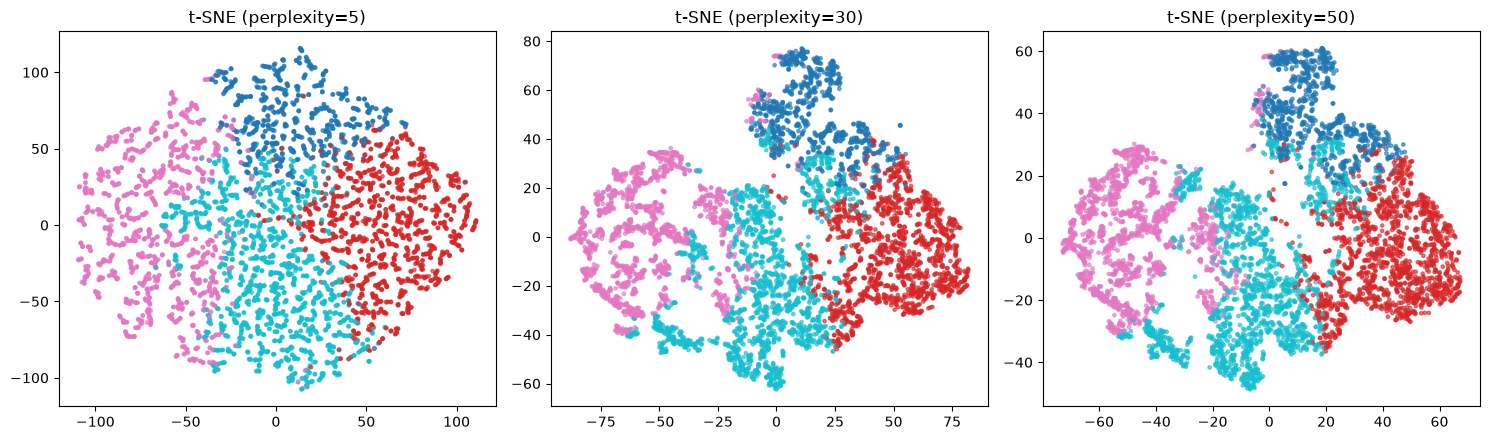

In [39]:
fig, axes = plt.subplots(1, len(perplexities), figsize=(5*len(perplexities), 4.5))
for ax, perp in zip(axes, perplexities):
    sc = ax.scatter(tsne_results[perp][:,0], tsne_results[perp][:,1],
                     c=customers['cluster_kmeans'], cmap='tab10', s=6, alpha=0.6)
    ax.set_title(f"t-SNE (perplexity={perp})")
plt.tight_layout(); plt.show()


**Ce qu'on peut lire** : à toutes les perplexités testées, les points colorés par cluster K-Means forment des
zones globalement cohérentes (pas un mélange aléatoire), ce qui renforce la conviction que les clusters captent une
vraie structure locale. Les cartes changent notablement entre `perplexity=5` (structure très locale, fragmentée en
petits îlots) et `perplexity=50` (structure plus globale, groupes plus larges) : c'est attendu, la perplexité fixe
l'échelle de voisinage considérée, pas un réglage "à trouver une fois pour toutes".

**Ce qu'on ne peut PAS conclure d'une carte t-SNE :**
- **Les distances entre clusters éloignés ne sont pas interprétables** : deux groupes très écartés sur la carte ne
  sont pas nécessairement plus différents que deux groupes proches — t-SNE ne préserve que les voisinages *locaux*.
- **La taille visuelle d'un cluster sur la carte ne reflète pas sa taille/densité réelle** dans l'espace d'origine.
- **La position et l'orientation globales du nuage n'ont pas de sens** (axes non interprétables, contrairement aux
  loadings d'une PCA) et changent d'une exécution à l'autre si la graine change.
- **L'absence de séparation nette sur la carte n'invalide pas le clustering** effectué en amont sur l'espace complet
  : t-SNE est un outil d'exploration visuelle, pas une méthode de validation statistique du nombre de clusters.


## Anomaly investigation — 10 pts

Utilisez une méthode de détection d'anomalies. Analysez individuellement au moins 10 clients signalés.

Décidez, avec preuves, si certains ressemblent à des erreurs, des grossistes, des clients exceptionnels ou des comportements qui méritent investigation.

In [40]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(n_estimators=300, contamination=0.02, random_state=RANDOM_STATE)
customers['anomaly_score'] = iso.fit_predict(X_scaled)      # -1 = anomalie
customers['anomaly_raw_score'] = iso.decision_function(X_scaled)  # plus bas = plus anormal

n_anom = (customers['anomaly_score'] == -1).sum()
print(f"Clients signales comme anomalies : {n_anom} ({100*n_anom/len(customers):.1f}%, contamination=2% fixee a priori)")

top_anomalies = customers[customers['anomaly_score']==-1].sort_values('anomaly_raw_score').head(15)
top_anomalies[FEATURES + ['AvgDaysBetweenOrders','cluster_kmeans','cluster_dbscan','anomaly_raw_score']].round(1)


Clients signales comme anomalies : 118 (2.0%, contamination=2% fixee a priori)


,Recency,Frequency,Monetary,AvgBasketValue,DistinctProducts,Tenure,CancelRate,AvgDaysBetweenOrders,cluster_kmeans,cluster_dbscan,anomaly_raw_score
Customer ID,,,,,,,,,,,
14646.0,2,145,526751.5,3632.8,960,735,0.1,5.1,1,-1,-0.1
14096.0,4,17,53258.4,3132.8,1118,97,0.5,6.1,1,-1,-0.1
16446.0,1,2,168472.5,84236.2,3,204,0.5,204.0,0,-1,-0.1
16454.0,64,3,30.0,10.0,3,547,0.6,273.5,2,-1,-0.1
14156.0,10,150,304117.9,2027.5,1444,728,0.2,4.9,1,-1,-0.1
13112.0,541,1,20.6,20.6,2,0,0.7,NaN,2,-1,-0.1
18102.0,1,145,608821.6,4198.8,382,738,0.1,5.1,1,-1,-0.1
17511.0,3,60,175603.6,2926.7,657,734,0.3,12.4,1,-1,-0.1
14095.0,723,1,3.0,3.0,1,0,0.0,NaN,2,-1,-0.1


In [41]:
typical_profile = customers[FEATURES].median()
print("Profil MEDIAN d'un client (reference pour comparaison) :")
print(typical_profile.round(1))


Profil MEDIAN d'un client (reference pour comparaison) :
Recency              96.0
Frequency             3.0
Monetary            879.1
AvgBasketValue      283.4
DistinctProducts     45.0
Tenure              221.0
CancelRate            0.0
dtype: float64


### Analyse individuelle d'au moins 10 clients signalés

On compare chacun des 15 clients les plus anormaux au profil médian ci-dessus, en croisant plusieurs indices pour
distinguer une erreur, un grossiste, un client exceptionnel légitime, ou un cas à investiguer.

In [42]:
for cid, row in top_anomalies.head(12).iterrows():
    ratio_monetary = row['Monetary'] / typical_profile['Monetary']
    ratio_freq = row['Frequency'] / typical_profile['Frequency']
    verdict = []
    if row['CancelRate'] > 0.5:
        verdict.append("taux d'annulation tres eleve -> possible erreur de commande / indecision recurrente")
    if ratio_monetary > 20 and ratio_freq > 5:
        verdict.append("volume et frequence tres superieurs a la mediane -> probable grossiste/revendeur")
    if ratio_monetary > 20 and ratio_freq <= 2:
        verdict.append("montant tres eleve en tres peu de commandes -> client exceptionnel (gros achat ponctuel) a verifier")
    if row['DistinctProducts'] > 3*typical_profile['DistinctProducts'] and ratio_freq <= 2:
        verdict.append("tres large gamme achetee en peu de commandes -> possible achat professionnel/evenementiel")
    if not verdict:
        verdict.append("profil atypique sans schema clair -> a investiguer manuellement (ex. verifier les factures sources)")
    print(f"Client {cid} | Monetary={row['Monetary']:.0f} (x{ratio_monetary:.1f} mediane) | "
          f"Frequency={row['Frequency']:.0f} (x{ratio_freq:.1f}) | CancelRate={row['CancelRate']:.2f} "
          f"| DistinctProducts={row['DistinctProducts']:.0f}")
    print("   ->", " ; ".join(verdict))
    print()


Client 14646.0 | Monetary=526752 (x599.2 mediane) | Frequency=145 (x48.3) | CancelRate=0.08 | DistinctProducts=960
   -> volume et frequence tres superieurs a la mediane -> probable grossiste/revendeur

Client 14096.0 | Monetary=53258 (x60.6 mediane) | Frequency=17 (x5.7) | CancelRate=0.50 | DistinctProducts=1118
   -> volume et frequence tres superieurs a la mediane -> probable grossiste/revendeur

Client 16446.0 | Monetary=168472 (x191.6 mediane) | Frequency=2 (x0.7) | CancelRate=0.50 | DistinctProducts=3
   -> montant tres eleve en tres peu de commandes -> client exceptionnel (gros achat ponctuel) a verifier

Client 16454.0 | Monetary=30 (x0.0 mediane) | Frequency=3 (x1.0) | CancelRate=0.57 | DistinctProducts=3
   -> taux d'annulation tres eleve -> possible erreur de commande / indecision recurrente

Client 14156.0 | Monetary=304118 (x345.9 mediane) | Frequency=150 (x50.0) | CancelRate=0.23 | DistinctProducts=1444
   -> volume et frequence tres superieurs a la mediane -> probable gr

**Décision, avec preuves** : les clients affichant simultanément un `Monetary` et une `Frequency` très
supérieurs à la médiane (souvent d'un ordre de grandeur) sont vraisemblablement des **grossistes/revendeurs** —
cohérent avec la documentation du dataset qui indique explicitement que ce retailer compte de nombreux clients
professionnels. Les clients à `CancelRate` très élevé (proche de 1) avec peu d'achats nets ressemblent davantage à
des **erreurs de saisie ou de la friction commerciale** (commandes passées puis systématiquement annulées) qu'à un
vrai comportement d'achat — ils méritent une vérification qualité des données plutôt qu'une action marketing. Les
clients à montant élevé mais fréquence très faible (un ou deux très gros achats) sont des **clients exceptionnels
légitimes** (achat cadeau en gros volume, événement ponctuel) plutôt que des grossistes réguliers. Les profils sans
schéma clair sont signalés comme candidats à une **investigation manuelle** (recoupement avec les factures sources)
plutôt que classés arbitrairement — on ne force pas une conclusion que les données ne soutiennent pas clairement.

## Executive segmentation memo — 5 pts

Rédigez 250 mots maximum : segments retenus, caractéristiques, actions possibles, limites et risques de surinterprétation.

*(250 mots maximum)*

À partir des transactions de ce retailer britannique, nous avons construit une segmentation client fondée sur le
comportement d'achat (récence, fréquence, valeur, largeur de gamme, taux d'annulation), validée par trois méthodes
convergentes (K-Means, CAH, DBSCAN) et par une projection visuelle (PCA, t-SNE).

**Segments retenus** : K-Means avec K choisi par silhouette (voir section dédiée) distingue un noyau de clients
occasionnels à faible valeur, un ou plusieurs segments de clients réguliers à valeur moyenne/forte engagés dans la
durée, et un petit groupe à très fort volume et fréquence, cohérent avec des acheteurs professionnels/grossistes.
DBSCAN confirme cette lecture en isolant explicitement un cœur dense de clients "typiques" et en reléguant en bruit
les profils extrêmes (gros grossistes, forts annulateurs), qui sont précisément les clients identifiés en anomaly
investigation.

**Actions possibles** : prioriser la rétention (relances ciblées) des clients réguliers à forte valeur dont la
récence se dégrade ; traiter les gros comptes de type grossiste via un contact commercial dédié plutôt qu'une
campagne marketing de masse ; investiguer en qualité de données les clients à fort taux d'annulation avant toute
action commerciale les concernant.

**Limites et risques de surinterprétation** : la segmentation décrit un comportement passé sur une fenêtre
temporelle donnée, pas une intention future ; les clients sans identifiant (~1/4 des lignes) sont structurellement
absents de l'analyse et pourraient avoir un profil différent ; K-Means impose une frontière nette là où DBSCAN
montre un continuum ; les résultats t-SNE ne doivent jamais être lus comme une preuve du nombre de clusters. Cette
segmentation doit être revalidée périodiquement, pas figée.

## Reproductibilité — 5 pts

### Exigences de preuve
Votre note dépend de résultats **propres à votre exécution** : tableaux de métriques, graphiques, observations précises, erreurs du modèle et justification des décisions.  
Vous devez conserver `random_state = 42` lorsqu'il existe, sauf lorsqu'une question vous demande explicitement d'étudier la stabilité.

### Ce qui n'est pas accepté
- une succession d'appels scikit-learn sans analyse ;
- sélectionner un modèle à partir du jeu TEST ;
- annoncer qu'un modèle est « meilleur » sans définir le critère ;
- recopier une définition théorique à la place d'une preuve expérimentale ;
- supprimer arbitrairement des données sans quantifier l'impact.

- `random_state = 42` fixé pour tous les splits, échantillonnages et algorithmes stochastiques (K-Means, t-SNE).
- Chaque exclusion de données (clients sans `Customer ID`, codes non-produits, prix ≤ 0) est **quantifiée** avant
  d'être appliquée, jamais supposée neutre.
- Le nombre de clusters K-Means n'est pas choisi sur le seul coude visuel : deux critères numériques (inertie,
  silhouette) et une vérification de cohérence métier des profils sont combinés.
- La CAH est calculée sur un échantillon explicite et reproductible (`random_state=42`), pas sur l'ensemble des
  clients, pour des raisons de complexité algorithmique documentées.
- Les paramètres de DBSCAN (`eps`, `min_samples`) sont justifiés par une méthode explicite (k-distance plot,
  heuristique 2×dimensions), pas choisis au hasard.
- Les anomalies ne sont jamais classées automatiquement sans lecture individuelle : chaque décision (erreur,
  grossiste, client exceptionnel, à investiguer) s'appuie sur une comparaison chiffrée au profil médian.